# Jamsil 2024 Subway-Based Weather And Temperature Weights

This notebook updates the weighting workflow so that:
- subway ridership is the main usage signal
- traffic inflow/outflow is the comparison feature set
- weather and temperature weights are computed separately
- weekday and weekend are analyzed separately
- outputs are saved to `Data/JSON/weather.json` and `Data/JSON/temp.json`

Reference logic reused from:
- `analystics_sub_new_24.ipynb`: subway hourly preprocessing style
- `Last_Comparison_2.ipynb`: day-type split, normalization, and metric comparison style

In [8]:
from __future__ import annotations

import json
import re
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

try:
    from IPython.display import display
except ImportError:
    display = print

font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Arial Unicode MS"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

PLOT_HOURS = list(range(6, 23))
PLOT_HOUR_KEYS = [f"{hour:02d}" for hour in PLOT_HOURS]
PLOT_HOUR_LABELS = [f"{hour:02d}시" for hour in PLOT_HOURS]
WEATHER_ORDER = ["rain", "snow", "clear", "cloudy"]
TEMP_CATEGORY_ORDER = ["verycold", "cold", "humid", "hot", "veryhot"]
HOLIDAY_DATES = pd.to_datetime([
    "2024-01-01",
    "2024-02-09", "2024-02-10", "2024-02-11", "2024-02-12",
    "2024-03-01",
    "2024-04-10",
    "2024-05-05", "2024-05-06", "2024-05-15",
    "2024-06-06",
    "2024-08-15",
    "2024-09-16", "2024-09-17", "2024-09-18",
    "2024-10-03", "2024-10-09",
    "2024-12-25",
]).normalize()
OUTLIER_DATES = pd.to_datetime([
    "2024-02-10",
    "2024-05-26",
    "2024-11-17",
    "2024-12-07",
    "2024-12-14",
]).normalize()
WEATHER_MAP = {
    "rain": "rain",
    "rainy": "rain",
    "rainfall": "rain",
    "snow": "snow",
    "snowy": "snow",
    "clear": "clear",
    "cloudy": "cloudy",
}


def normalize_text(value: object) -> str:
    return re.sub(r"\s+", "", str(value)).strip()


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "Data").exists() and (candidate / "Note").exists():
            return candidate
    return current


def resolve_existing_path(project_root: Path, *relative_candidates: str) -> Path:
    for relative_path in relative_candidates:
        path = project_root / relative_path
        if path.exists():
            return path
    raise FileNotFoundError(f"None of the candidate paths exist: {relative_candidates}")


def resolve_first_glob_path(directory: Path, pattern: str) -> Path:
    matches = sorted(directory.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files matched pattern={pattern!r} in {directory}")
    return matches[0]


def read_csv_with_fallback_encodings(path: Path, encodings: list[str] | None = None) -> pd.DataFrame:
    encodings = encodings or ["cp949", "euc-kr", "utf-8-sig", "utf-8"]
    for encoding in encodings:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("csv", b"", 0, 1, f"Unable to read {path} with fallback encodings")


def label_day_type(series: pd.Series) -> pd.Series:
    dt = pd.to_datetime(series).dt.normalize()
    is_weekend_or_holiday = (dt.dt.dayofweek >= 5) | dt.isin(HOLIDAY_DATES)
    return pd.Series(np.where(is_weekend_or_holiday, "weekend", "weekday"), index=series.index)


def minmax_scale(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").astype(float)
    min_value = s.min()
    max_value = s.max()
    if pd.isna(min_value) or pd.isna(max_value) or min_value == max_value:
        return pd.Series(0.0, index=s.index, dtype=float)
    return (s - min_value) / (max_value - min_value)


def groupwise_minmax(df: pd.DataFrame, group_col: str, value_col: str, output_col: str) -> pd.DataFrame:
    scaled_parts = []
    for group_name, group in df.groupby(group_col, sort=False):
        scaled_group = group.copy()
        scaled_group[output_col] = minmax_scale(scaled_group[value_col])
        scaled_parts.append(scaled_group)
    return pd.concat(scaled_parts, ignore_index=True)


def pick_direction_label(values: list[str], keywords: list[str]) -> str:
    cleaned_values = [str(value).strip() for value in values if pd.notna(value)]
    for keyword in keywords:
        for value in cleaned_values:
            if keyword in value:
                return value
    raise ValueError(f"Direction label not found for keywords={keywords}, values={cleaned_values}")


def metric_row(curve_label: str, baseline_series: pd.Series, compare_series: pd.Series) -> dict[str, object]:
    aligned_df = pd.concat(
        [baseline_series.rename("baseline"), compare_series.rename("compare")],
        axis=1,
    ).dropna()
    if aligned_df.empty:
        return {"curve": curve_label, "corr": np.nan, "mae": np.nan, "rmse": np.nan}

    diff = aligned_df["compare"] - aligned_df["baseline"]
    return {
        "curve": curve_label,
        "corr": float(aligned_df["baseline"].corr(aligned_df["compare"])),
        "mae": float(diff.abs().mean()),
        "rmse": float(np.sqrt((diff ** 2).mean())),
    }


def to_python_float(value: float | int | None) -> float | None:
    if pd.isna(value):
        return None
    return round(float(value), 6)


PROJECT_ROOT = find_project_root()
METRO_DIR = resolve_existing_path(PROJECT_ROOT, "Data/Metro")
SUBWAY_PATH = resolve_first_glob_path(METRO_DIR, "*24.1~24.12*csv")
SUBWAY_STATION_KEYWORDS = ["여의도", "여의나루"]
TRAFFIC_DIR = resolve_existing_path(PROJECT_ROOT, "Data/Trafficdata")
TRAFFIC_LOCATION_NAMES = ["서강대교", "마포대교", "원효대교"]
WEATHER_PATH = resolve_existing_path(PROJECT_ROOT, "Data/jamsil_2024.csv")
JSON_DIR = PROJECT_ROOT / "Data" / "JSON"
LEGACY_YEOUIDO_JSON = PROJECT_ROOT / "Data" / "yeouido_weights_2024.json"
MOVED_YEOUIDO_JSON = JSON_DIR / "yeouido_weights_2024.json"
WEATHER_JSON_PATH = JSON_DIR / "weather.json"
TEMP_JSON_PATH = JSON_DIR / "temp.json"

print(f"Project root: {PROJECT_ROOT}")
print(f"Subway source: {SUBWAY_PATH}")
print(f"Subway station keywords: {SUBWAY_STATION_KEYWORDS}")
print(f"Traffic source dir: {TRAFFIC_DIR}")
print(f"Traffic location names: {TRAFFIC_LOCATION_NAMES}")
print(f"Weather source: {WEATHER_PATH}")


Project root: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL
Subway source: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/Data/Metro/서울교통공사_역별 시간대별 승하차인원(24.1~24.12) (1).csv
Subway station keywords: ['여의도', '여의나루']
Traffic source dir: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/Data/Trafficdata
Traffic location names: ['서강대교', '마포대교', '원효대교']
Weather source: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/Data/jamsil_2024.csv


## 1. Explicit Preprocessing

This section keeps preprocessing explicit:
- date parsing
- outlier-date removal
- weekday/weekend split
- hour filtering `06`~`22`
- merge subway / traffic / weather
- temperature categories derived from 2024 temperature distribution

In [9]:
subway_raw = read_csv_with_fallback_encodings(SUBWAY_PATH)
subway_raw.columns = [str(col).strip() for col in subway_raw.columns]
subway_raw = subway_raw[subway_raw["역명"].astype(str).apply(lambda value: any(keyword in value for keyword in SUBWAY_STATION_KEYWORDS))].copy()
subway_raw["날짜"] = pd.to_datetime(subway_raw["날짜"], errors="coerce").dt.normalize()
subway_raw = subway_raw.dropna(subset=["날짜"]).copy()
subway_raw = subway_raw[~subway_raw["날짜"].isin(OUTLIER_DATES)].copy()
subway_raw["day_type"] = label_day_type(subway_raw["날짜"])

subway_hour_cols = [
    col for col in subway_raw.columns
    if re.match(r"^\d{2}시-\d{2}시$", normalize_text(col))
]
subway_hour_cols = [col for col in subway_hour_cols if int(normalize_text(col)[:2]) in PLOT_HOURS]
subway_hour_map = {col: f"{int(normalize_text(col)[:2]):02d}" for col in subway_hour_cols}

subway_daily_df = (
    subway_raw
    .groupby(["날짜", "day_type", "구분"], as_index=False)[subway_hour_cols]
    .sum()
)
subway_direction_values = subway_daily_df["구분"].dropna().astype(str).str.strip().unique().tolist()
subway_entry_label = pick_direction_label(subway_direction_values, ["승차", "입"])
subway_exit_label = pick_direction_label(subway_direction_values, ["하차", "출"])

subway_entry_long_df = (
    subway_daily_df[subway_daily_df["구분"] == subway_entry_label]
    .melt(id_vars=["날짜", "day_type"], value_vars=subway_hour_cols, var_name="hour_col", value_name="subway_entry")
)
subway_exit_long_df = (
    subway_daily_df[subway_daily_df["구분"] == subway_exit_label]
    .melt(id_vars=["날짜", "day_type"], value_vars=subway_hour_cols, var_name="hour_col", value_name="subway_exit")
)
subway_hourly_df = subway_entry_long_df.merge(
    subway_exit_long_df,
    on=["날짜", "day_type", "hour_col"],
    how="inner",
    validate="one_to_one",
)
subway_hourly_df["hour"] = subway_hourly_df["hour_col"].map(subway_hour_map)
subway_hourly_df["hour_order"] = subway_hourly_df["hour"].astype(int)
subway_hourly_df["hour_label"] = subway_hourly_df["hour"].map(lambda value: f"{int(value):02d}시")
subway_hourly_df["date"] = subway_hourly_df["날짜"]
subway_hourly_df["datetime"] = subway_hourly_df["date"] + pd.to_timedelta(subway_hourly_df["hour_order"], unit="h")
subway_hourly_df[["subway_entry", "subway_exit"]] = subway_hourly_df[["subway_entry", "subway_exit"]].apply(pd.to_numeric, errors="coerce").fillna(0)
subway_hourly_df["test_raw"] = subway_hourly_df["subway_exit"] - subway_hourly_df["subway_entry"]
subway_hourly_df["test_direction"] = np.where(subway_hourly_df["subway_exit"] >= subway_hourly_df["subway_entry"], "increase", "decrease")
subway_hourly_df = groupwise_minmax(subway_hourly_df, "day_type", "test_raw", "test")
subway_hourly_df = subway_hourly_df.sort_values(["date", "hour_order"]).reset_index(drop=True)

canonical_hours = [f"{hour:02d}시" for hour in range(6, 24)]
traffic_frames = []
traffic_location_keys = {normalize_text(name) for name in TRAFFIC_LOCATION_NAMES}

for month in range(1, 13):
    month_files = sorted((TRAFFIC_DIR).glob(f"{month:02d}*2024*.xlsx"))
    if not month_files:
        raise FileNotFoundError(f"Traffic file not found for month={month:02d}")

    traffic_file = month_files[0]
    excel_file = pd.ExcelFile(traffic_file)
    loaded_df = None

    for sheet_name in excel_file.sheet_names:
        for header_row in range(3):
            try:
                raw_df = pd.read_excel(traffic_file, sheet_name=sheet_name, header=header_row)
            except Exception:
                continue

            raw_df.columns = [str(col).strip() for col in raw_df.columns]
            normalized_cols = {col: normalize_text(col) for col in raw_df.columns}
            location_col = next((col for col, norm in normalized_cols.items() if "지점명" in norm or "지점명칭" in norm), None)
            date_col = next((col for col, norm in normalized_cols.items() if norm == "일자" or "날짜" in norm), None)
            direction_col = next((col for col, norm in normalized_cols.items() if "방향" in norm), None)
            if not location_col or not date_col or not direction_col:
                continue

            hour_map = {}
            for hour in range(6, 24):
                candidates = [
                    col for col, norm in normalized_cols.items()
                    if norm in {f"{hour:02d}시", f"{hour}시"}
                ]
                if not candidates:
                    hour_map = {}
                    break
                hour_map[f"{hour:02d}시"] = candidates[0]

            if len(hour_map) != len(canonical_hours):
                continue

            location_mask = raw_df[location_col].astype(str).map(lambda value: normalize_text(value) in traffic_location_keys)
            if not location_mask.any():
                continue

            loaded_df = raw_df.loc[location_mask, [date_col, direction_col] + list(hour_map.values())].copy()
            loaded_df = loaded_df.rename(columns={
                date_col: "date_raw",
                direction_col: "방향",
                **{value: key for key, value in hour_map.items()},
            })
            traffic_frames.append(loaded_df)
            break
        if loaded_df is not None:
            break

    if loaded_df is None:
        raise RuntimeError(f"Traffic rows not found for {TRAFFIC_LOCATION_NAMES} in {traffic_file.name}")

traffic_raw = pd.concat(traffic_frames, ignore_index=True)
traffic_raw["date"] = pd.to_datetime(traffic_raw["date_raw"].astype(str), format="%Y%m%d", errors="coerce").dt.normalize()
traffic_raw = traffic_raw.dropna(subset=["date"]).copy()
traffic_raw = traffic_raw[~traffic_raw["date"].isin(OUTLIER_DATES)].copy()
traffic_raw["day_type"] = label_day_type(traffic_raw["date"])
for col in canonical_hours:
    traffic_raw[col] = pd.to_numeric(traffic_raw[col], errors="coerce").fillna(0)

traffic_daily_df = traffic_raw.groupby(["date", "day_type", "방향"], as_index=False)[canonical_hours].sum()
traffic_direction_values = traffic_daily_df["방향"].dropna().astype(str).str.strip().unique().tolist()
traffic_in_label = pick_direction_label(traffic_direction_values, ["유입", "입"])
traffic_out_label = pick_direction_label(traffic_direction_values, ["유출", "출"])

traffic_in_long_df = (
    traffic_daily_df[traffic_daily_df["방향"] == traffic_in_label]
    .melt(id_vars=["date", "day_type"], value_vars=PLOT_HOUR_LABELS, var_name="hour_label", value_name="traffic_in")
)
traffic_out_long_df = (
    traffic_daily_df[traffic_daily_df["방향"] == traffic_out_label]
    .melt(id_vars=["date", "day_type"], value_vars=PLOT_HOUR_LABELS, var_name="hour_label", value_name="traffic_out")
)
traffic_hourly_df = traffic_in_long_df.merge(
    traffic_out_long_df,
    on=["date", "day_type", "hour_label"],
    how="inner",
    validate="one_to_one",
)
traffic_hourly_df["hour"] = traffic_hourly_df["hour_label"].str.replace("시", "", regex=False)
traffic_hourly_df["hour_order"] = traffic_hourly_df["hour"].astype(int)
traffic_hourly_df["datetime"] = traffic_hourly_df["date"] + pd.to_timedelta(traffic_hourly_df["hour_order"], unit="h")
traffic_hourly_df = groupwise_minmax(traffic_hourly_df, "day_type", "traffic_in", "traffic_in_norm")
traffic_hourly_df = groupwise_minmax(traffic_hourly_df, "day_type", "traffic_out", "traffic_out_norm")
traffic_hourly_df = traffic_hourly_df.sort_values(["date", "hour_order"]).reset_index(drop=True)

weather_df = pd.read_csv(WEATHER_PATH)
if "datetime" in weather_df.columns:
    weather_df["datetime"] = pd.to_datetime(weather_df["datetime"], errors="coerce").dt.floor("h")
else:
    weather_df["datetime"] = pd.to_datetime(
        weather_df["date"].astype(str).str.strip() + " " + weather_df["hour"].astype(str).str.zfill(2),
        format="%Y-%m-%d %H",
        errors="coerce",
    )
weather_df["date"] = weather_df["datetime"].dt.normalize()
weather_df["hour_order"] = weather_df["datetime"].dt.hour
weather_df["hour"] = weather_df["hour_order"].map(lambda value: f"{int(value):02d}" if pd.notna(value) else pd.NA)
weather_df["hour_label"] = weather_df["hour_order"].map(lambda value: f"{int(value):02d}시" if pd.notna(value) else pd.NA)
weather_df["weather"] = weather_df["weather"].astype(str).str.strip().str.lower().map(WEATHER_MAP)
weather_df["temperature_c"] = pd.to_numeric(weather_df["temperature_c"], errors="coerce")
weather_df = weather_df.dropna(subset=["datetime", "date", "hour_order", "weather", "temperature_c"]).copy()
weather_df = weather_df[~weather_df["date"].isin(OUTLIER_DATES)].copy()
weather_df["day_type"] = label_day_type(weather_df["date"])

# Quantile-based classification derived from 2024 temperature distribution.
temperature_rank = weather_df["temperature_c"].rank(method="first")
weather_df["temp_category"] = pd.qcut(
    temperature_rank,
    q=len(TEMP_CATEGORY_ORDER),
    labels=TEMP_CATEGORY_ORDER,
)
temp_category_ranges_df = (
    weather_df.groupby("temp_category", observed=False)["temperature_c"]
    .agg(["min", "max", "count"])
    .reindex(TEMP_CATEGORY_ORDER)
    .reset_index()
)
weather_df = weather_df.sort_values("datetime").reset_index(drop=True)

usage_df = subway_hourly_df.merge(
    traffic_hourly_df[["datetime", "traffic_in", "traffic_out", "traffic_in_norm", "traffic_out_norm"]],
    on="datetime",
    how="inner",
    validate="one_to_one",
)
analysis_df = usage_df.merge(
    weather_df[["datetime", "weather", "temperature_c", "temp_category"]],
    on="datetime",
    how="left",
    validate="one_to_one",
)

weather_hour_coverage = sorted(weather_df["hour_order"].dropna().astype(int).unique().tolist())
print(f"Subway hourly rows: {len(subway_hourly_df)}")
print(f"Traffic hourly rows: {len(traffic_hourly_df)}")
print(f"Usage rows after subway/traffic merge: {len(usage_df)}")
print(f"Analysis rows after weather merge: {len(analysis_df)}")
print(f"Weather hour coverage in source: {weather_hour_coverage}")
if 6 not in weather_hour_coverage:
    print("Note: Data/jamsil_2024.csv does not include 06:00 weather rows, so 06시 weather/temp outputs remain null.")
print()
display(
    analysis_df[[
        "datetime",
        "day_type",
        "hour_label",
        "subway_entry",
        "subway_exit",
        "test_raw",
        "test_direction",
        "test",
        "traffic_in",
        "traffic_out",
        "traffic_in_norm",
        "traffic_out_norm",
        "weather",
        "temperature_c",
        "temp_category",
    ]].head(20)
)

print("\nTemperature category ranges derived from 2024 hourly weather distribution:")
display(temp_category_ranges_df)


Subway hourly rows: 6137
Traffic hourly rows: 6137
Usage rows after subway/traffic merge: 6137
Analysis rows after weather merge: 6137
Weather hour coverage in source: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Note: Data/jamsil_2024.csv does not include 06:00 weather rows, so 06시 weather/temp outputs remain null.



,datetime,day_type,hour_label,subway_entry,subway_exit,test_raw,test_direction,test,traffic_in,traffic_out,traffic_in_norm,traffic_out_norm,weather,temperature_c,temp_category
0,2024-01-01 06:00:00,weekend,06시,138,458,320,increase,0.520305,1166.0,838.0,0.147857,0.123290,NaN,NaN,NaN
1,2024-01-01 07:00:00,weekend,07시,208,642,434,increase,0.523328,1570.0,1498.0,0.199087,0.220391,clear,-3.3,verycold
2,2024-01-01 08:00:00,weekend,08시,592,490,-102,decrease,0.509111,2120.0,1632.0,0.268831,0.240106,clear,-4.1,verycold
3,2024-01-01 09:00:00,weekend,09시,238,585,347,increase,0.521021,2411.0,2256.0,0.305732,0.331911,clear,-1.7,verycold
4,2024-01-01 10:00:00,weekend,10시,201,541,340,increase,0.520835,3153.0,2726.0,0.399822,0.401059,clear,1.6,verycold
5,2024-01-01 11:00:00,weekend,11시,433,672,239,increase,0.518156,3906.0,3399.0,0.495308,0.500074,clear,4.0,cold
6,2024-01-01 12:00:00,weekend,12시,610,856,246,increase,0.518342,4124.0,3593.0,0.522952,0.528616,clear,5.8,cold
7,2024-01-01 13:00:00,weekend,13시,631,988,357,increase,0.521286,3991.0,3889.0,0.506087,0.572164,cloudy,6.3,cold
8,2024-01-01 14:00:00,weekend,14시,849,1020,171,increase,0.516352,4317.0,3850.0,0.547426,0.566426,cloudy,6.7,cold
9,2024-01-01 15:00:00,weekend,15시,883,908,25,increase,0.512480,4482.0,3837.0,0.568349,0.564514,cloudy,6.7,cold



Temperature category ranges derived from 2024 hourly weather distribution:


,temp_category,min,max,count
0,verycold,-14.8,2.5,1156
1,cold,2.5,12.0,1155
2,humid,12.0,19.5,1155
3,hot,19.5,25.7,1155
4,veryhot,25.7,34.9,1155


## 2. Subway Baseline Vs Traffic Inflow/Outflow

This section follows the `Last_Comparison_2.ipynb` comparison style:
- median hourly curves
- normalized values
- weekday/weekend split
- `corr`, `mae`, `rmse` comparison

In [10]:
baseline_curve_df = (
    usage_df
    .groupby(["day_type", "hour_label", "hour_order"], as_index=False)["test"]
    .median()
    .rename(columns={"test": "baseline_test"})
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)
traffic_curve_df = (
    usage_df
    .groupby(["day_type", "hour_label", "hour_order"], as_index=False)[["traffic_in_norm", "traffic_out_norm"]]
    .median()
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)

traffic_comparison_rows = []
for day_type in ["weekday", "weekend"]:
    baseline_series = (
        baseline_curve_df[baseline_curve_df["day_type"] == day_type]
        .set_index("hour_label")["baseline_test"]
        .reindex(PLOT_HOUR_LABELS)
    )
    day_curve_df = traffic_curve_df[traffic_curve_df["day_type"] == day_type].set_index("hour_label")
    traffic_comparison_rows.append({"day_type": day_type, **metric_row("traffic_in_norm", baseline_series, day_curve_df["traffic_in_norm"].reindex(PLOT_HOUR_LABELS))})
    traffic_comparison_rows.append({"day_type": day_type, **metric_row("traffic_out_norm", baseline_series, day_curve_df["traffic_out_norm"].reindex(PLOT_HOUR_LABELS))})

traffic_comparison_df = pd.DataFrame(traffic_comparison_rows)
display(traffic_comparison_df)


,day_type,curve,corr,mae,rmse
0,weekday,traffic_in_norm,0.218673,0.244828,0.318992
1,weekday,traffic_out_norm,0.310521,0.274726,0.334563
2,weekend,traffic_in_norm,0.432521,0.121122,0.139944
3,weekend,traffic_out_norm,0.233932,0.172146,0.193277


## 3. Weather And Temperature Weight Curves

Weights are stored as median hourly values of the normalized subway `test` signal.
- weather weights: grouped only by weather category
- temperature weights: grouped only by temperature category
- no weather × temperature combinations

In [11]:
weather_curve_source_df = analysis_df.dropna(subset=["weather"]).rename(columns={"weather": "weather_category"}).copy()
weather_weight_df = (
    weather_curve_source_df
    .groupby(["day_type", "hour_label", "hour_order", "weather_category"], observed=False)
    .agg(sample_size=("test", "size"), weight=("test", "median"))
    .reset_index()
    .sort_values(["day_type", "hour_order", "weather_category"])
    .reset_index(drop=True)
)
temp_curve_source_df = analysis_df.dropna(subset=["temp_category"]).copy()
temp_curve_source_df["temp_category"] = temp_curve_source_df["temp_category"].astype(str)
temp_curve_source_df = temp_curve_source_df.rename(columns={"temp_category": "temp_category_label"})
temp_weight_df = (
    temp_curve_source_df
    .groupby(["day_type", "hour_label", "hour_order", "temp_category_label"], observed=True)
    .agg(sample_size=("test", "size"), weight=("test", "median"))
    .reset_index()
    .sort_values(["day_type", "hour_order", "temp_category_label"])
    .reset_index(drop=True)
)

display(weather_weight_df.head(20))
display(temp_weight_df.head(20))


,day_type,hour_label,hour_order,weather_category,sample_size,weight
0,weekday,07시,7,clear,102,0.711215
1,weekday,07시,7,cloudy,111,0.705989
2,weekday,07시,7,rain,29,0.714817
3,weekday,07시,7,snow,5,0.695539
4,weekday,08시,8,clear,100,0.887673
5,weekday,08시,8,cloudy,116,0.887633
6,weekday,08시,8,rain,26,0.890661
7,weekday,08시,8,snow,5,0.913345
8,weekday,09시,9,clear,108,0.550671
9,weekday,09시,9,cloudy,99,0.549384


,day_type,hour_label,hour_order,temp_category_label,sample_size,weight
0,weekday,07시,7,cold,54,0.708305
1,weekday,07시,7,hot,51,0.716203
2,weekday,07시,7,humid,46,0.716183
3,weekday,07시,7,verycold,82,0.698785
4,weekday,07시,7,veryhot,14,0.705693
5,weekday,08시,8,cold,49,0.897866
6,weekday,08시,8,hot,52,0.887336
7,weekday,08시,8,humid,45,0.886069
8,weekday,08시,8,verycold,79,0.889118
9,weekday,08시,8,veryhot,22,0.863426


## 4. Visualizations, Metrics, And JSON Save

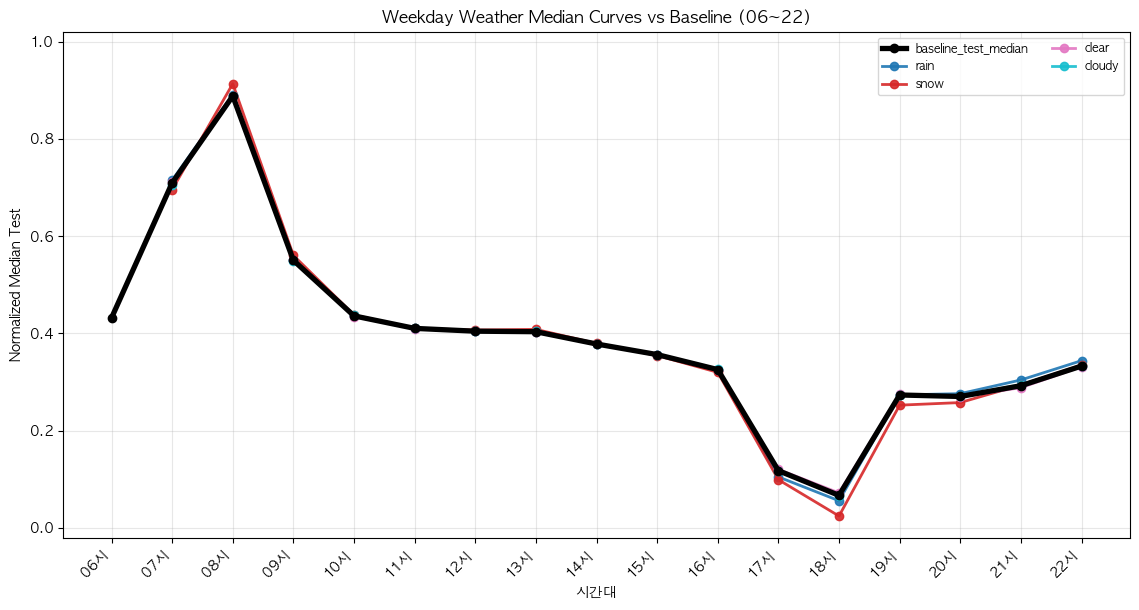

Weekday Weather Median Curves vs Baseline (06~22) metrics


,curve,corr,mae,rmse
0,rain,0.999580,0.004050,0.006256
1,snow,0.998739,0.010335,0.015333
2,clear,0.999953,0.001419,0.001965
3,cloudy,0.999986,0.000761,0.001152


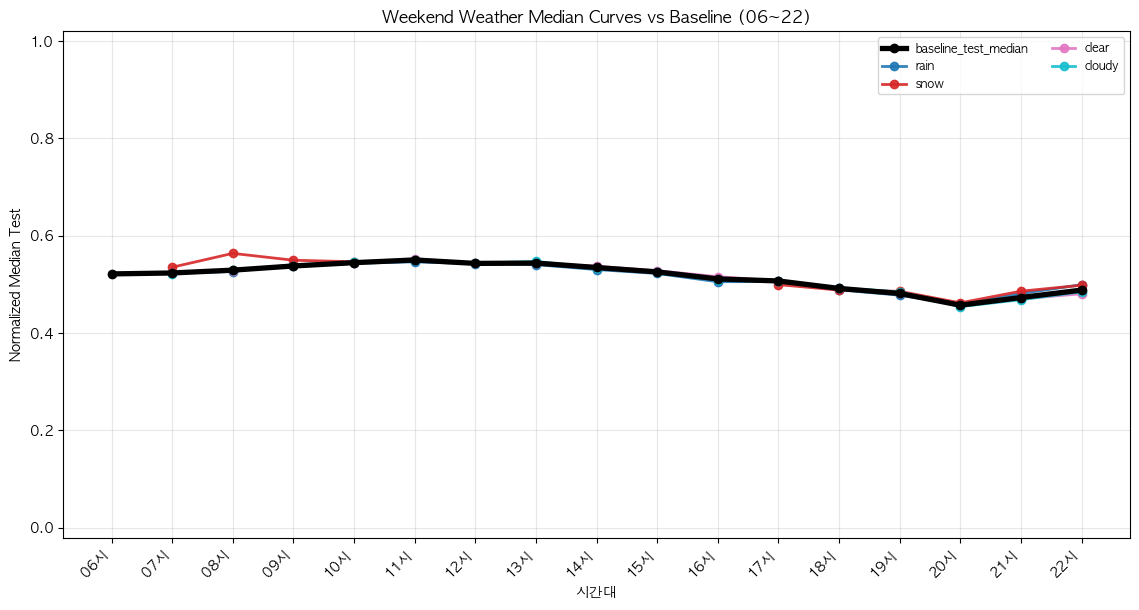

Weekend Weather Median Curves vs Baseline (06~22) metrics


,curve,corr,mae,rmse
0,rain,0.988639,0.003484,0.004448
1,snow,0.945888,0.010307,0.013597
2,clear,0.996463,0.001761,0.002630
3,cloudy,0.997975,0.001582,0.002151


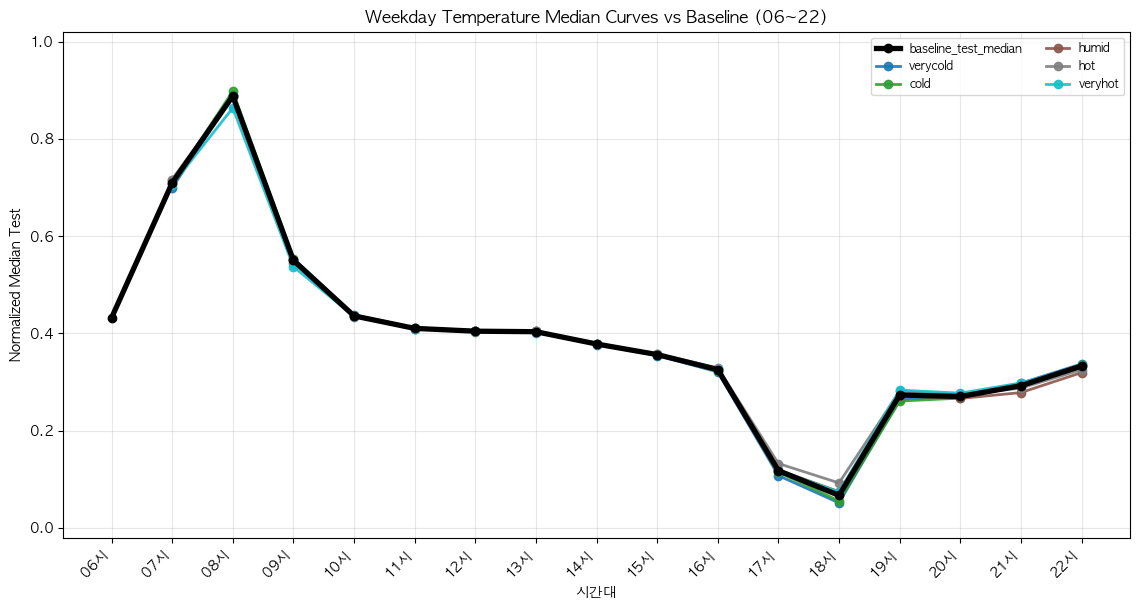

Weekday Temperature Median Curves vs Baseline (06~22) metrics


,curve,corr,mae,rmse
0,verycold,0.999604,0.004513,0.006245
1,cold,0.999847,0.003276,0.005209
2,humid,0.999583,0.003805,0.005726
3,hot,0.999348,0.005296,0.008296
4,veryhot,0.999719,0.004760,0.007977


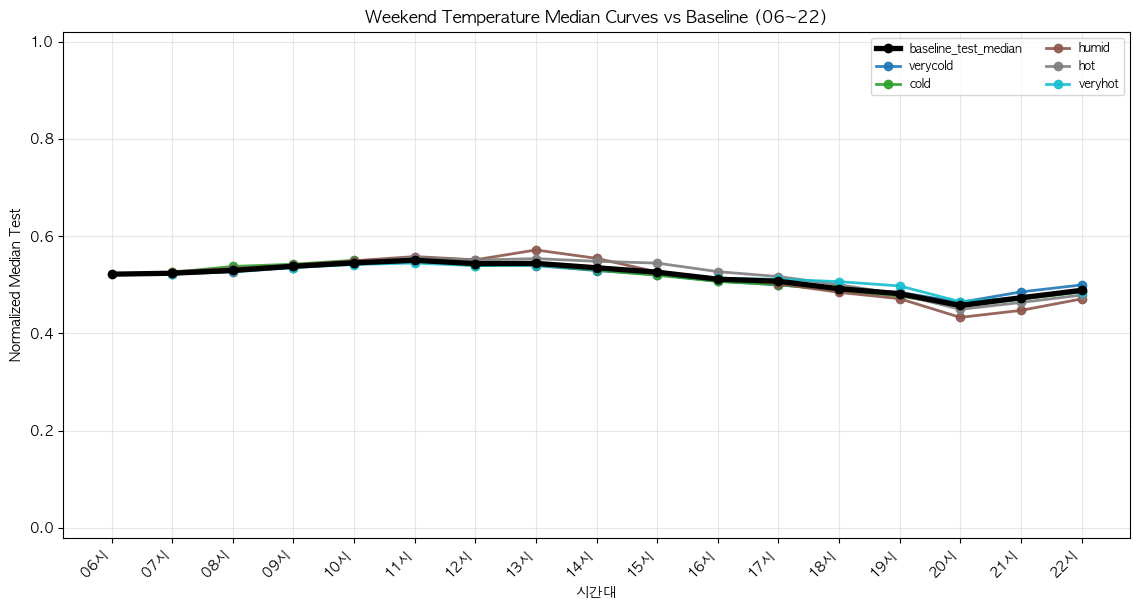

Weekend Temperature Median Curves vs Baseline (06~22) metrics


,curve,corr,mae,rmse
0,verycold,0.986326,0.004603,0.005612
1,cold,0.990709,0.004251,0.004620
2,humid,0.986832,0.010595,0.013888
3,hot,0.976499,0.007409,0.009212
4,veryhot,0.982294,0.004459,0.006339


Saved weather.json -> /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/Data/JSON/weather.json
Saved temp.json -> /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/Data/JSON/temp.json
Moved yeouido_weights_2024.json -> /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/Data/JSON/yeouido_weights_2024.json

Weather JSON preview:
{
  "weekday": {
    "06": {
      "rain": null,
      "snow": null,
      "clear": null,
      "cloudy": null
    },
    "07": {
      "rain": 0.714817,
      "snow": 0.695539,
      "clear": 0.711215,
      "cloudy": 0.705989
    }
  },
  "weekend": {
    "06": {
      "rain": null,
      "snow": null,
      "clear": null,
      "cloudy": null
    },
    "07": {
      "rain": 0.522997,
      "snow": 0.53537,
      "clear": 0.524296,
      "cloudy": 0.522042
    }
  }
}

Temp JSON preview:
{
  "weekday": {
    "06": {
      "verycold": null,
      "cold": null,
      "humid": n

,type,day_type,hour,reference_category,threshold,status,train_samples,train_accuracy,train_roc_auc,train_log_loss,valid_samples,valid_accuracy,valid_roc_auc,valid_log_loss,test_samples,test_accuracy,test_roc_auc,test_log_loss,weight_prob_corr
0,weather,weekday,07,rain,0.708840,fit,173,0.560694,0.559877,0.685294,37,0.540541,0.583333,0.686811,37,0.594595,0.595455,0.679304,0.953797
1,weather,weekday,08,rain,0.887692,fit,173,0.543353,0.551991,0.681489,37,0.459459,0.513158,0.690938,37,0.459459,0.453869,0.702615,0.975610
2,weather,weekday,09,rain,0.550295,fit,173,0.566474,0.576985,0.681075,38,0.447368,0.436111,0.709342,36,0.444444,0.426984,0.711545,0.880046
3,weather,weekday,10,rain,0.435988,fit,174,0.557471,0.564606,0.685843,38,0.394737,0.399160,0.721183,35,0.685714,0.704545,0.663612,0.068924
4,weather,weekday,11,rain,0.410356,fit,173,0.537572,0.557338,0.687253,37,0.486486,0.474702,0.703119,37,0.459459,0.491176,0.696685,0.676542
5,weather,weekday,12,rain,0.404418,fit,173,0.537572,0.551699,0.686931,38,0.552632,0.551136,0.679341,36,0.583333,0.561905,0.686533,0.990621
6,weather,weekday,13,rain,0.403507,fit,173,0.572254,0.577072,0.681710,37,0.729730,0.762821,0.650143,37,0.432432,0.435673,0.719170,0.866446
7,weather,weekday,14,rain,0.378172,fit,173,0.526012,0.532745,0.691354,37,0.378378,0.346491,0.707763,37,0.729730,0.752941,0.671401,0.393702
8,weather,weekday,15,rain,0.356478,fit,173,0.543353,0.563152,0.680801,38,0.421053,0.394203,0.706408,36,0.555556,0.520635,0.694400,0.972425
9,weather,weekday,16,rain,0.325205,fit,173,0.543353,0.559743,0.682553,37,0.621622,0.610606,0.691175,37,0.513514,0.539474,0.691259,0.991971



Category-level weight vs logistic probability check:


,type,day_type,hour,category,weight,logit_prob,weight_minus_logit_prob,train_samples,train_positive_rate,valid_samples,valid_positive_rate,test_samples,test_positive_rate
0,weather,weekday,07,rain,0.714817,0.544271,0.170546,20,0.600000,4,0.250000,5,0.600000
1,weather,weekday,07,snow,0.695539,0.397921,0.297617,4,0.250000,1,0.000000,0,NaN
2,weather,weekday,07,clear,0.711215,0.549026,0.162189,71,0.549296,15,0.600000,16,0.687500
3,weather,weekday,07,cloudy,0.705989,0.453391,0.252598,78,0.448718,17,0.470588,16,0.500000
4,weather,weekday,08,rain,0.890661,0.531458,0.359204,18,0.500000,4,0.750000,4,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,weather,weekend,09,cloudy,0.537572,0.490610,0.046962,33,0.484848,7,0.142857,7,0.714286
76,weather,weekend,10,rain,0.543593,0.499702,0.043891,13,0.461538,3,0.666667,3,0.000000
77,weather,weekend,10,snow,0.546696,0.598711,-0.052015,1,1.000000,0,NaN,0,NaN
78,weather,weekend,10,clear,0.544362,0.441857,0.102505,39,0.435897,8,0.625000,9,0.666667



Average validation/test metrics by type:


,type,valid_accuracy,valid_roc_auc,test_accuracy,test_roc_auc,weight_prob_corr
0,temperature,0.634437,0.678662,0.610028,0.636580,0.869222
1,weather,0.529740,0.540054,0.538890,0.542956,0.803032


In [12]:
def build_weight_json(curve_df: pd.DataFrame, category_col: str, categories: list[str]) -> dict[str, dict[str, dict[str, float | None]]]:
    payload: dict[str, dict[str, dict[str, float | None]]] = {"weekday": {}, "weekend": {}}
    for day_type in ["weekday", "weekend"]:
        day_df = curve_df[curve_df["day_type"] == day_type].copy()
        for hour_key, hour_label in zip(PLOT_HOUR_KEYS, PLOT_HOUR_LABELS):
            hour_df = day_df[day_df["hour_label"] == hour_label]
            hour_weights = hour_df.groupby(category_col)["weight"].median()
            payload[day_type][hour_key] = {
                category: to_python_float(hour_weights.get(category, np.nan))
                for category in categories
            }
    return payload


def plot_category_curves(
    baseline_df: pd.DataFrame,
    category_df: pd.DataFrame,
    day_type: str,
    category_col: str,
    categories: list[str],
    title: str,
):
    baseline_series = (
        baseline_df[baseline_df["day_type"] == day_type]
        .set_index("hour_label")["baseline_test"]
        .reindex(PLOT_HOUR_LABELS)
    )
    day_category_df = category_df[category_df["day_type"] == day_type].copy()

    fig, ax = plt.subplots(figsize=(11.5, 6.2))
    x_positions = range(len(PLOT_HOUR_LABELS))
    ax.plot(
        x_positions,
        baseline_series.values,
        color="black",
        linewidth=3.8,
        marker="o",
        label="baseline_test_median",
        zorder=4,
    )

    metrics_rows = []
    color_map = plt.get_cmap("tab10", max(len(categories), 1))
    for idx, category in enumerate(categories):
        curve_series = (
            day_category_df[day_category_df[category_col] == category]
            .groupby("hour_label")["weight"]
            .median()
            .reindex(PLOT_HOUR_LABELS)
        )
        ax.plot(
            x_positions,
            curve_series.values,
            linewidth=2.0,
            marker="o",
            color=color_map(idx),
            alpha=0.9,
            label=category,
        )
        metrics_rows.append(metric_row(category, baseline_series, curve_series))

    ax.set_title(title)
    ax.set_xlabel("시간대")
    ax.set_ylabel("Normalized Median Test")
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(PLOT_HOUR_LABELS, rotation=45, ha="right")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8.5, ncol=2)
    plt.tight_layout()
    plt.show()

    metrics_df = pd.DataFrame(metrics_rows)
    print(f"{title} metrics")
    display(metrics_df)
    return metrics_df


weekday_weather_metrics_df = plot_category_curves(
    baseline_curve_df,
    weather_weight_df,
    day_type="weekday",
    category_col="weather_category",
    categories=WEATHER_ORDER,
    title="Weekday Weather Median Curves vs Baseline (06~22)",
)
weekend_weather_metrics_df = plot_category_curves(
    baseline_curve_df,
    weather_weight_df,
    day_type="weekend",
    category_col="weather_category",
    categories=WEATHER_ORDER,
    title="Weekend Weather Median Curves vs Baseline (06~22)",
)
weekday_temp_metrics_df = plot_category_curves(
    baseline_curve_df,
    temp_weight_df,
    day_type="weekday",
    category_col="temp_category_label",
    categories=TEMP_CATEGORY_ORDER,
    title="Weekday Temperature Median Curves vs Baseline (06~22)",
)
weekend_temp_metrics_df = plot_category_curves(
    baseline_curve_df,
    temp_weight_df,
    day_type="weekend",
    category_col="temp_category_label",
    categories=TEMP_CATEGORY_ORDER,
    title="Weekend Temperature Median Curves vs Baseline (06~22)",
)

weather_json = build_weight_json(weather_weight_df, "weather_category", WEATHER_ORDER)
temp_json = build_weight_json(temp_weight_df, "temp_category_label", TEMP_CATEGORY_ORDER)

JSON_DIR.mkdir(parents=True, exist_ok=True)
if LEGACY_YEOUIDO_JSON.exists():
    if MOVED_YEOUIDO_JSON.exists():
        MOVED_YEOUIDO_JSON.unlink()
    shutil.move(str(LEGACY_YEOUIDO_JSON), str(MOVED_YEOUIDO_JSON))

WEATHER_JSON_PATH.write_text(json.dumps(weather_json, ensure_ascii=False, indent=2), encoding="utf-8")
TEMP_JSON_PATH.write_text(json.dumps(temp_json, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Saved weather.json -> {WEATHER_JSON_PATH}")
print(f"Saved temp.json -> {TEMP_JSON_PATH}")
print(f"Moved yeouido_weights_2024.json -> {MOVED_YEOUIDO_JSON if MOVED_YEOUIDO_JSON.exists() else 'not moved'}")
print("\nWeather JSON preview:")
print(json.dumps({k: dict(list(v.items())[:2]) for k, v in weather_json.items()}, ensure_ascii=False, indent=2))
print("\nTemp JSON preview:")
print(json.dumps({k: dict(list(v.items())[:2]) for k, v in temp_json.items()}, ensure_ascii=False, indent=2))

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score

model_df = analysis_df.dropna(subset=["weather", "temp_category"]).copy()
model_df = model_df[model_df["hour_order"].between(7, 22)].copy()
model_df["temp_category"] = model_df["temp_category"].astype(str)


def assign_split_within_category(df: pd.DataFrame, feature_col: str, random_state: int = 42) -> pd.DataFrame:
    split_parts = []
    for category in pd.Categorical(df[feature_col].astype(str), categories=sorted(df[feature_col].astype(str).unique())).categories:
        category_subset = df[df[feature_col].astype(str) == category].sample(frac=1, random_state=random_state).copy()
        if category_subset.empty:
            continue
        n_samples = len(category_subset)
        train_end = max(1, min(n_samples, int(round(n_samples * 0.7))))
        valid_size = int(round(n_samples * 0.15))
        if n_samples >= 3:
            valid_size = max(1, min(valid_size, n_samples - train_end - 1))
        else:
            valid_size = max(0, min(valid_size, n_samples - train_end))
        valid_end = train_end + valid_size
        split_values = np.array(["train"] * n_samples, dtype=object)
        split_values[train_end:valid_end] = "valid"
        split_values[valid_end:] = "test"
        category_subset["split"] = split_values
        split_parts.append(category_subset)
    if not split_parts:
        return df.assign(split=pd.NA)
    return pd.concat(split_parts, ignore_index=False).sort_index()


def encode_single_category(df: pd.DataFrame, feature_col: str, category_order: list[str], reference_category: str) -> pd.DataFrame:
    category_series = pd.Categorical(df[feature_col].astype(str), categories=category_order)
    encoded_df = pd.get_dummies(category_series, prefix=feature_col, dtype=float)
    reference_col = f"{feature_col}_{reference_category}"
    if reference_col in encoded_df.columns:
        encoded_df = encoded_df.drop(columns=[reference_col])
    if encoded_df.shape[1] == 0:
        encoded_df = pd.DataFrame({"constant_feature": np.zeros(len(df), dtype=float)}, index=df.index)
    return encoded_df


def split_metrics(model, feature_df: pd.DataFrame, target_series: pd.Series) -> dict[str, float | int | None]:
    if feature_df.empty:
        return {"samples": 0, "positive_rate": None, "accuracy": None, "roc_auc": None, "log_loss": None, "brier": None}
    probabilities = model.predict_proba(feature_df)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    positive_rate = float(target_series.mean()) if len(target_series) else np.nan
    return {
        "samples": int(len(target_series)),
        "positive_rate": to_python_float(positive_rate),
        "accuracy": to_python_float(accuracy_score(target_series, predictions)),
        "roc_auc": to_python_float(roc_auc_score(target_series, probabilities)) if target_series.nunique() > 1 else None,
        "log_loss": to_python_float(log_loss(target_series, probabilities, labels=[0, 1])),
        "brier": to_python_float(brier_score_loss(target_series, probabilities)),
    }


def run_logistic_validation(
    df: pd.DataFrame,
    feature_col: str,
    category_order: list[str],
    weight_df: pd.DataFrame,
    weight_category_col: str,
    validation_type: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_rows = []
    detail_rows = []
    reference_category = category_order[0]

    for day_type in ["weekday", "weekend"]:
        for hour_label in [label for label in PLOT_HOUR_LABELS if label != "06시"]:
            subset = df[(df["day_type"] == day_type) & (df["hour_label"] == hour_label)].copy()
            if subset.empty:
                continue

            subset = assign_split_within_category(subset, feature_col=feature_col, random_state=42)
            train_subset = subset[subset["split"] == "train"].copy()
            valid_subset = subset[subset["split"] == "valid"].copy()
            test_subset = subset[subset["split"] == "test"].copy()
            if train_subset.empty or test_subset.empty:
                continue

            threshold = float(train_subset["test"].median())
            for split_subset in [train_subset, valid_subset, test_subset]:
                split_subset["target_binary"] = (split_subset["test"] >= threshold).astype(int)

            train_target = train_subset["target_binary"]
            if train_target.nunique() < 2:
                summary_rows.append({
                    "type": validation_type,
                    "day_type": day_type,
                    "hour": hour_label.replace("시", ""),
                    "reference_category": reference_category,
                    "threshold": to_python_float(threshold),
                    "status": "skipped_single_train_class",
                })
                continue

            x_train = encode_single_category(train_subset, feature_col, category_order, reference_category)
            x_valid = encode_single_category(valid_subset, feature_col, category_order, reference_category)
            x_test = encode_single_category(test_subset, feature_col, category_order, reference_category)

            model = LogisticRegression(solver="liblinear", max_iter=1000, random_state=42)
            model.fit(x_train, train_target)

            train_metrics = split_metrics(model, x_train, train_target)
            valid_metrics = split_metrics(model, x_valid, valid_subset["target_binary"])
            test_metrics = split_metrics(model, x_test, test_subset["target_binary"])

            category_probabilities = {}
            for category in category_order:
                category_row = pd.DataFrame(0.0, index=[0], columns=x_train.columns)
                category_col_name = f"{feature_col}_{category}"
                if category_col_name in category_row.columns:
                    category_row.loc[0, category_col_name] = 1.0
                category_probabilities[category] = float(model.predict_proba(category_row)[0, 1])

            hour_weights = (
                weight_df[(weight_df["day_type"] == day_type) & (weight_df["hour_label"] == hour_label)]
                .groupby(weight_category_col)["weight"]
                .median()
            )

            comparison_rows = []
            for category in category_order:
                train_category = train_subset[train_subset[feature_col].astype(str) == category]
                valid_category = valid_subset[valid_subset[feature_col].astype(str) == category]
                test_category = test_subset[test_subset[feature_col].astype(str) == category]
                weight_value = hour_weights.get(category, np.nan)
                predicted_probability = category_probabilities.get(category, np.nan)
                detail_rows.append({
                    "type": validation_type,
                    "day_type": day_type,
                    "hour": hour_label.replace("시", ""),
                    "category": category,
                    "weight": to_python_float(weight_value),
                    "logit_prob": to_python_float(predicted_probability),
                    "weight_minus_logit_prob": to_python_float(weight_value - predicted_probability) if pd.notna(weight_value) and pd.notna(predicted_probability) else None,
                    "train_samples": int(len(train_category)),
                    "train_positive_rate": to_python_float(train_category["target_binary"].mean()) if len(train_category) else None,
                    "valid_samples": int(len(valid_category)),
                    "valid_positive_rate": to_python_float(valid_category["target_binary"].mean()) if len(valid_category) else None,
                    "test_samples": int(len(test_category)),
                    "test_positive_rate": to_python_float(test_category["target_binary"].mean()) if len(test_category) else None,
                })
                if pd.notna(weight_value) and pd.notna(predicted_probability) and len(train_category) > 0:
                    comparison_rows.append({"category": category, "weight": float(weight_value), "logit_prob": float(predicted_probability)})

            comparison_df = pd.DataFrame(comparison_rows)
            summary_rows.append({
                "type": validation_type,
                "day_type": day_type,
                "hour": hour_label.replace("시", ""),
                "reference_category": reference_category,
                "threshold": to_python_float(threshold),
                "status": "fit",
                "train_samples": train_metrics["samples"],
                "train_accuracy": train_metrics["accuracy"],
                "train_roc_auc": train_metrics["roc_auc"],
                "train_log_loss": train_metrics["log_loss"],
                "valid_samples": valid_metrics["samples"],
                "valid_accuracy": valid_metrics["accuracy"],
                "valid_roc_auc": valid_metrics["roc_auc"],
                "valid_log_loss": valid_metrics["log_loss"],
                "test_samples": test_metrics["samples"],
                "test_accuracy": test_metrics["accuracy"],
                "test_roc_auc": test_metrics["roc_auc"],
                "test_log_loss": test_metrics["log_loss"],
                "weight_prob_corr": to_python_float(comparison_df["weight"].corr(comparison_df["logit_prob"])) if len(comparison_df) >= 2 else None,
            })

    return pd.DataFrame(summary_rows), pd.DataFrame(detail_rows)


weather_logistic_summary_df, weather_logistic_detail_df = run_logistic_validation(
    model_df,
    feature_col="weather",
    category_order=WEATHER_ORDER,
    weight_df=weather_weight_df,
    weight_category_col="weather_category",
    validation_type="weather",
)
temp_logistic_summary_df, temp_logistic_detail_df = run_logistic_validation(
    model_df,
    feature_col="temp_category",
    category_order=TEMP_CATEGORY_ORDER,
    weight_df=temp_weight_df,
    weight_category_col="temp_category_label",
    validation_type="temperature",
)

logistic_validation_summary_df = pd.concat([weather_logistic_summary_df, temp_logistic_summary_df], ignore_index=True)
logistic_validation_detail_df = pd.concat([weather_logistic_detail_df, temp_logistic_detail_df], ignore_index=True)

print("\nLogistic validation summary (train/valid/test):")
display(logistic_validation_summary_df.head(40))
print("\nCategory-level weight vs logistic probability check:")
display(logistic_validation_detail_df.head(80))
print("\nAverage validation/test metrics by type:")
display(
    logistic_validation_summary_df[logistic_validation_summary_df["status"] == "fit"]
    .groupby("type", as_index=False)[["valid_accuracy", "valid_roc_auc", "test_accuracy", "test_roc_auc", "weight_prob_corr"]]
    .mean(numeric_only=True)
)


## 5. Subway Baseline Vs Day-Of-Week Medians

This section ignores weather and temperature, and compares subway-only hourly medians.
- baseline: weekday or weekend/holiday subway `test` median by hour
- overlay: Monday to Sunday hourly medians within each day-type bucket
- outlier dates above remain excluded because `subway_hourly_df` was already filtered

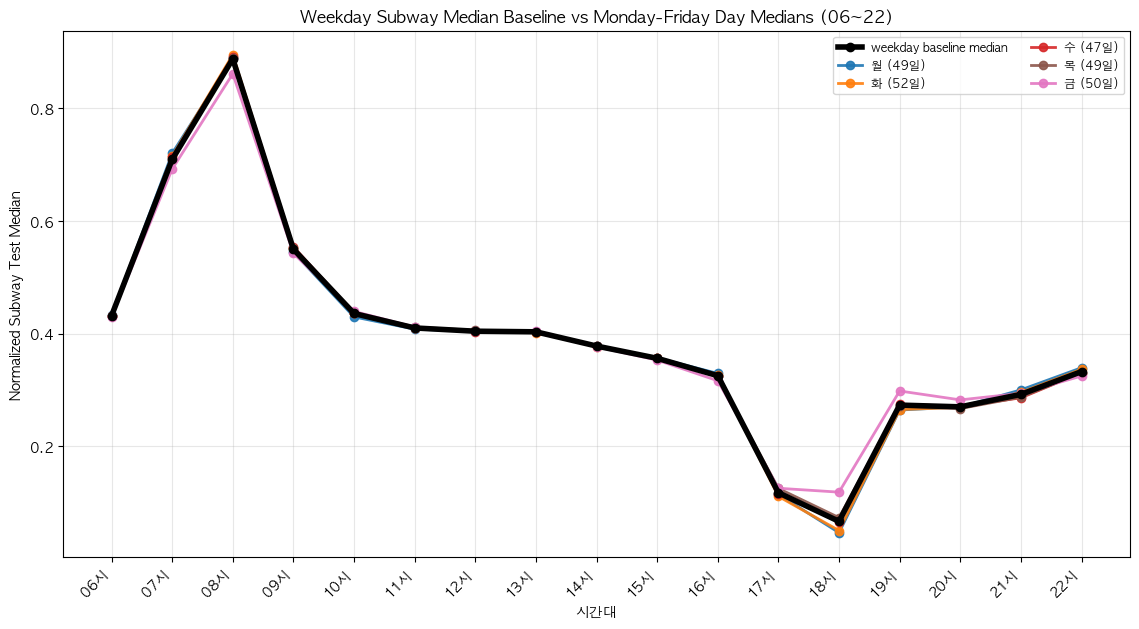

Weekday Subway Median Baseline vs Monday-Friday Day Medians (06~22) day counts


,weekday_label,date_count
0,월,49
1,화,52
2,수,47
3,목,49
4,금,50


Weekday Subway Median Baseline vs Monday-Friday Day Medians (06~22) corr vs baseline


,weekday_label,date_count,corr_vs_baseline
0,월,49,0.999495
1,화,52,0.999841
2,수,47,0.999950
3,목,49,0.999877
4,금,50,0.998305


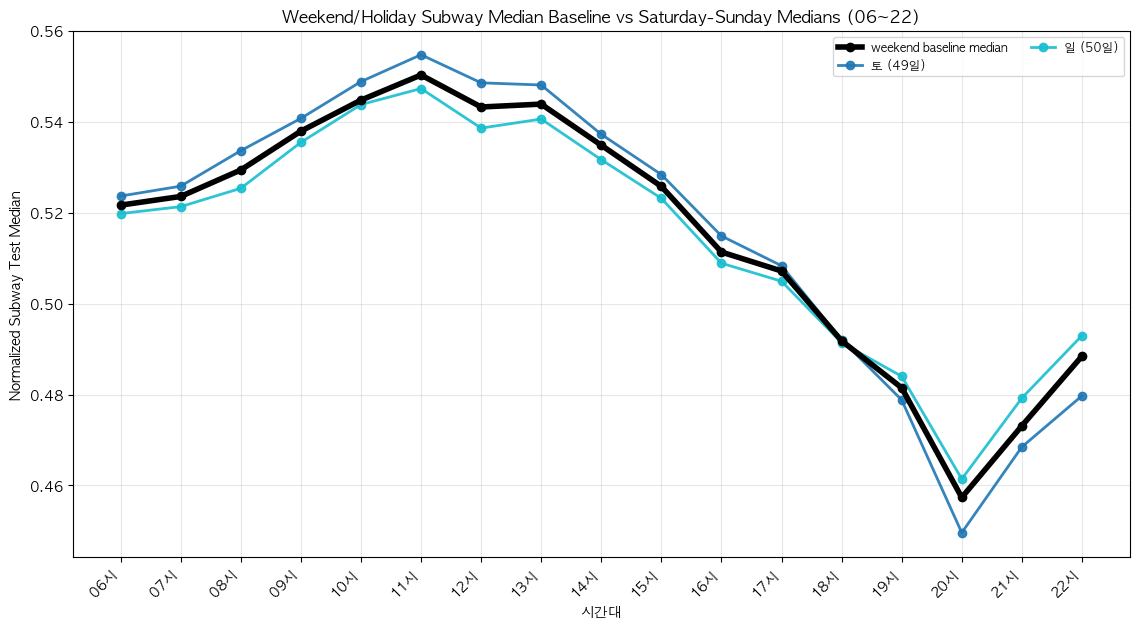

Weekend/Holiday Subway Median Baseline vs Saturday-Sunday Medians (06~22) day counts


,weekday_label,date_count
10,토,49
11,일,50


Weekend/Holiday Subway Median Baseline vs Saturday-Sunday Medians (06~22) corr vs baseline


,weekday_label,date_count,corr_vs_baseline
0,토,49,0.998062
1,일,50,0.997879


In [13]:
DAY_LABEL_MAP = {0: "월", 1: "화", 2: "수", 3: "목", 4: "금", 5: "토", 6: "일"}
DAY_ORDER = list(DAY_LABEL_MAP.items())

subway_day_curve_source_df = subway_hourly_df.copy()
subway_day_curve_source_df["weekday_num"] = pd.to_datetime(subway_day_curve_source_df["date"]).dt.dayofweek
subway_day_curve_source_df["weekday_label"] = subway_day_curve_source_df["weekday_num"].map(DAY_LABEL_MAP)

subway_daytype_baseline_df = (
    subway_day_curve_source_df
    .groupby(["day_type", "hour_label", "hour_order"], as_index=False)["test"]
    .median()
    .rename(columns={"test": "baseline_test_median"})
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)
subway_weekday_curve_df = (
    subway_day_curve_source_df
    .groupby(["day_type", "weekday_num", "weekday_label", "hour_label", "hour_order"], as_index=False)["test"]
    .median()
    .rename(columns={"test": "weekday_test_median"})
    .sort_values(["day_type", "weekday_num", "hour_order"])
    .reset_index(drop=True)
)
subway_weekday_date_count_df = (
    subway_day_curve_source_df
    .groupby(["day_type", "weekday_num", "weekday_label"], as_index=False)["date"]
    .nunique()
    .rename(columns={"date": "date_count"})
    .sort_values(["day_type", "weekday_num"])
    .reset_index(drop=True)
)


def plot_subway_dayofweek_overlay(
    baseline_df: pd.DataFrame,
    weekday_curve_df: pd.DataFrame,
    date_count_df: pd.DataFrame,
    day_type: str,
    title: str,
    weekday_numbers: list[int] | None = None,
):
    baseline_series = (
        baseline_df[baseline_df["day_type"] == day_type]
        .set_index("hour_label")["baseline_test_median"]
        .reindex(PLOT_HOUR_LABELS)
    )
    day_curve_subset = weekday_curve_df[weekday_curve_df["day_type"] == day_type].copy()
    day_count_subset = date_count_df[date_count_df["day_type"] == day_type].copy()

    fig, ax = plt.subplots(figsize=(11.5, 6.4))
    x_positions = range(len(PLOT_HOUR_LABELS))
    ax.plot(
        x_positions,
        baseline_series.values,
        color="black",
        linewidth=4.0,
        marker="o",
        label=f"{day_type} baseline median",
        zorder=5,
    )

    plot_day_order = [(weekday_num, weekday_label) for weekday_num, weekday_label in DAY_ORDER if weekday_numbers is None or weekday_num in weekday_numbers]
    color_map = plt.get_cmap("tab10", len(plot_day_order))
    corr_rows = []
    for color_idx, (weekday_num, weekday_label) in enumerate(plot_day_order):
        curve_series = (
            day_curve_subset[day_curve_subset["weekday_num"] == weekday_num]
            .set_index("hour_label")["weekday_test_median"]
            .reindex(PLOT_HOUR_LABELS)
        )
        if curve_series.notna().sum() == 0:
            continue

        date_count_series = day_count_subset.loc[day_count_subset["weekday_num"] == weekday_num, "date_count"]
        date_count = int(date_count_series.iloc[0]) if not date_count_series.empty else 0
        aligned_df = pd.concat(
            [baseline_series.rename("baseline"), curve_series.rename("weekday_curve")],
            axis=1,
        ).dropna()
        corr_rows.append({
            "weekday_label": weekday_label,
            "date_count": date_count,
            "corr_vs_baseline": float(aligned_df["baseline"].corr(aligned_df["weekday_curve"])) if len(aligned_df) >= 2 else np.nan,
        })
        ax.plot(
            x_positions,
            curve_series.values,
            linewidth=2.0,
            marker="o",
            color=color_map(color_idx),
            alpha=0.9,
            label=f"{weekday_label} ({date_count}일)",
        )

    ax.set_title(title)
    ax.set_xlabel("시간대")
    ax.set_ylabel("Normalized Subway Test Median")
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(PLOT_HOUR_LABELS, rotation=45, ha="right")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8.5, ncol=2)
    plt.tight_layout()
    plt.show()

    if weekday_numbers is not None:
        day_count_subset = day_count_subset[day_count_subset["weekday_num"].isin(weekday_numbers)].copy()
    summary_df = day_count_subset[["weekday_label", "date_count"]].copy()
    print(f"{title} day counts")
    display(summary_df)
    corr_df = pd.DataFrame(corr_rows)
    print(f"{title} corr vs baseline")
    display(corr_df)


plot_subway_dayofweek_overlay(
    subway_daytype_baseline_df,
    subway_weekday_curve_df,
    subway_weekday_date_count_df,
    day_type="weekday",
    title="Weekday Subway Median Baseline vs Monday-Friday Day Medians (06~22)",
)
plot_subway_dayofweek_overlay(
    subway_daytype_baseline_df,
    subway_weekday_curve_df,
    subway_weekday_date_count_df,
    day_type="weekend",
    title="Weekend/Holiday Subway Median Baseline vs Saturday-Sunday Medians (06~22)",
    weekday_numbers=[5, 6],
)


## 6. Subway Overall Baseline Vs Weekday/Weekend Lines

This section ignores weather and temperature. It samples weekday and weekend/holiday dates at a 1:1 ratio for the black baseline, then overlays full weekday and weekend/holiday median curves.

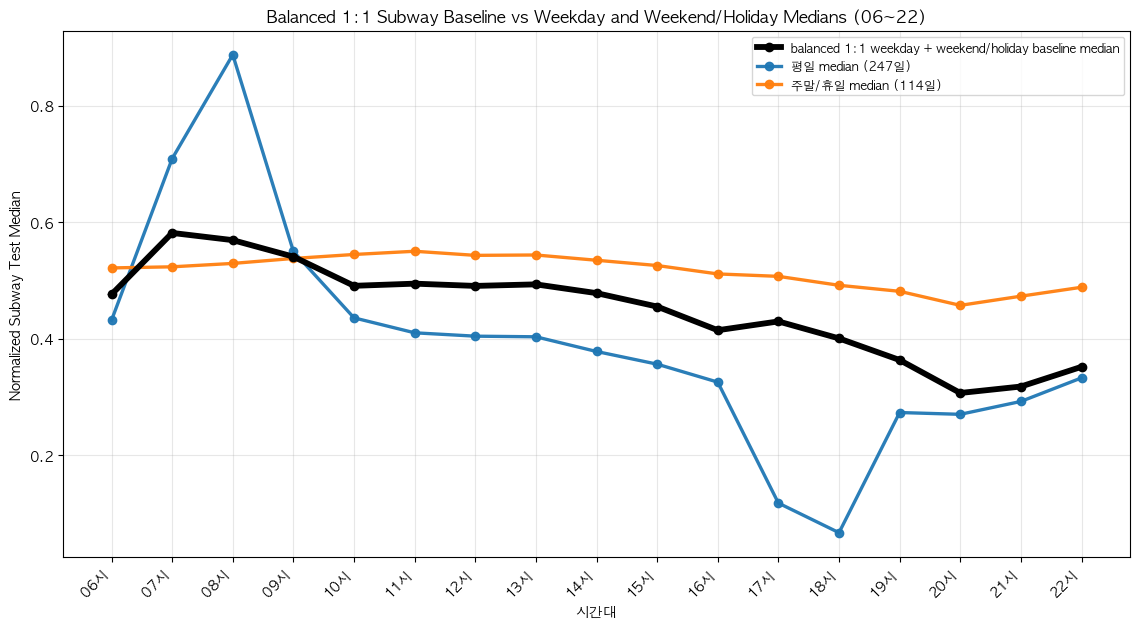

Weekday/weekend lines corr vs balanced 1:1 weekday+weekend baseline


,day_type,full_date_count,baseline_sampled_date_count,corr_vs_balanced_baseline
0,평일,247,114,0.744628
1,주말/휴일,114,114,0.857565


In [14]:
BASELINE_SAMPLE_RANDOM_STATE = 42
daytype_date_pool_df = subway_hourly_df[["day_type", "date"]].drop_duplicates().copy()
weekday_dates = daytype_date_pool_df.loc[daytype_date_pool_df["day_type"] == "weekday", "date"].sort_values().tolist()
weekend_dates = daytype_date_pool_df.loc[daytype_date_pool_df["day_type"] == "weekend", "date"].sort_values().tolist()
balanced_date_count = min(len(weekday_dates), len(weekend_dates))

balanced_weekday_dates = pd.Series(weekday_dates).sample(n=balanced_date_count, random_state=BASELINE_SAMPLE_RANDOM_STATE).tolist()
balanced_weekend_dates = pd.Series(weekend_dates).sample(n=balanced_date_count, random_state=BASELINE_SAMPLE_RANDOM_STATE).tolist()
balanced_baseline_dates_df = pd.concat([
    pd.DataFrame({"day_type": "weekday", "date": balanced_weekday_dates}),
    pd.DataFrame({"day_type": "weekend", "date": balanced_weekend_dates}),
], ignore_index=True)
balanced_overall_baseline_source_df = subway_hourly_df.merge(
    balanced_baseline_dates_df,
    on=["day_type", "date"],
    how="inner",
    validate="many_to_one",
)
baseline_sample_count_df = (
    balanced_baseline_dates_df
    .groupby("day_type", as_index=False)["date"]
    .nunique()
    .rename(columns={"date": "baseline_sampled_date_count"})
)

subway_overall_baseline_df = (
    balanced_overall_baseline_source_df
    .groupby(["hour_label", "hour_order"], as_index=False)["test"]
    .median()
    .rename(columns={"test": "overall_baseline_median"})
    .sort_values("hour_order")
    .reset_index(drop=True)
)
subway_daytype_curve_df = (
    subway_hourly_df
    .groupby(["day_type", "hour_label", "hour_order"], as_index=False)["test"]
    .median()
    .rename(columns={"test": "daytype_median"})
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)
subway_daytype_count_df = (
    subway_hourly_df
    .groupby("day_type", as_index=False)["date"]
    .nunique()
    .rename(columns={"date": "date_count"})
)

overall_baseline_series = (
    subway_overall_baseline_df
    .set_index("hour_label")["overall_baseline_median"]
    .reindex(PLOT_HOUR_LABELS)
)

fig, ax = plt.subplots(figsize=(11.5, 6.4))
x_positions = range(len(PLOT_HOUR_LABELS))
ax.plot(
    x_positions,
    overall_baseline_series.values,
    color="black",
    linewidth=4.2,
    marker="o",
    label="balanced 1:1 weekday + weekend/holiday baseline median",
    zorder=5,
)

daytype_plot_specs = [
    ("weekday", "평일", "#1f77b4"),
    ("weekend", "주말/휴일", "#ff7f0e"),
]
daytype_corr_rows = []
for day_type, label, color in daytype_plot_specs:
    curve_series = (
        subway_daytype_curve_df[subway_daytype_curve_df["day_type"] == day_type]
        .set_index("hour_label")["daytype_median"]
        .reindex(PLOT_HOUR_LABELS)
    )
    aligned_df = pd.concat(
        [overall_baseline_series.rename("baseline"), curve_series.rename("curve")],
        axis=1,
    ).dropna()
    date_count_series = subway_daytype_count_df.loc[subway_daytype_count_df["day_type"] == day_type, "date_count"]
    date_count = int(date_count_series.iloc[0]) if not date_count_series.empty else 0
    sample_count_series = baseline_sample_count_df.loc[baseline_sample_count_df["day_type"] == day_type, "baseline_sampled_date_count"]
    sampled_date_count = int(sample_count_series.iloc[0]) if not sample_count_series.empty else 0
    daytype_corr_rows.append({
        "day_type": label,
        "full_date_count": date_count,
        "baseline_sampled_date_count": sampled_date_count,
        "corr_vs_balanced_baseline": float(aligned_df["baseline"].corr(aligned_df["curve"])) if len(aligned_df) >= 2 else np.nan,
    })
    ax.plot(
        x_positions,
        curve_series.values,
        linewidth=2.4,
        marker="o",
        color=color,
        alpha=0.95,
        label=f"{label} median ({date_count}일)",
    )

ax.set_title("Balanced 1:1 Subway Baseline vs Weekday and Weekend/Holiday Medians (06~22)")
ax.set_xlabel("시간대")
ax.set_ylabel("Normalized Subway Test Median")
ax.set_xticks(list(x_positions))
ax.set_xticklabels(PLOT_HOUR_LABELS, rotation=45, ha="right")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8.7)
plt.tight_layout()
plt.show()

daytype_corr_df = pd.DataFrame(daytype_corr_rows)
print("Weekday/weekend lines corr vs balanced 1:1 weekday+weekend baseline")
display(daytype_corr_df)
